# Tutorial 2 Exercise Solutions

This concise, standalone notebook provides complete solutions for Exercises E.1–E.3. It uses **simulated voltage data and included result tables only**; no real customer measurements are included.


## 1. Initialisation and simulated data

Import the required packages, locate the Tutorial 2 folder, and load the simulated test voltages, topology and included per-customer result table.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

WORKING_DIRECTORY = Path.cwd()
folder_candidates = [
    WORKING_DIRECTORY,
    WORKING_DIRECTORY / "Tutorial_2_MV_Effects_Reference_Voltage",
    WORKING_DIRECTORY.parent / "Tutorial_2_MV_Effects_Reference_Voltage",
]

for candidate in folder_candidates:
    if (candidate / "data").exists() and (candidate / "results").exists():
        TUTORIAL_DIRECTORY = candidate
        break
else:
    raise FileNotFoundError("Could not find the Tutorial 2 folder.")

DATA_DIRECTORY = TUTORIAL_DIRECTORY / "data"
RESULTS_DIRECTORY = TUTORIAL_DIRECTORY / "results"
STEPS_PER_DAY = 24 * 60 // 5


def load_matrix(dataset_name, split, file_name):
    path = DATA_DIRECTORY / dataset_name / split / file_name
    return (
        pd.read_pickle(path)
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(np.float32)
    )


V_lv_te = load_matrix("synthetic_data_5_min_LV", "test", "V.pkl")
V_mv_te = load_matrix("synthetic_data_5_min_MV", "test", "V.pkl")
mv_effect_test = V_mv_te - V_lv_te
hours = np.arange(STEPS_PER_DAY) * 5 / 60

per_customer_metrics = pd.read_csv(
    TUTORIAL_DIRECTORY / "MV_core_final_per_customer_results.csv"
)
topology = pd.read_csv(
    TUTORIAL_DIRECTORY / "network" / "customer_topology.csv"
).sort_values("customer")
customer_mv_effect = topology[["customer", "phase", "hops"]].copy()
customer_mv_effect["RMS MV effect (V)"] = np.sqrt(
    np.mean(mv_effect_test ** 2, axis=0)
)

## 2. E.1: Inspect the MV Effect for One Customer

Plot one test day of `V_MV - V_LV` and report its mean and standard deviation.


Customer C16, test day 1
Mean MV effect: -1.3820 V
Std. MV effect: 0.4947 V


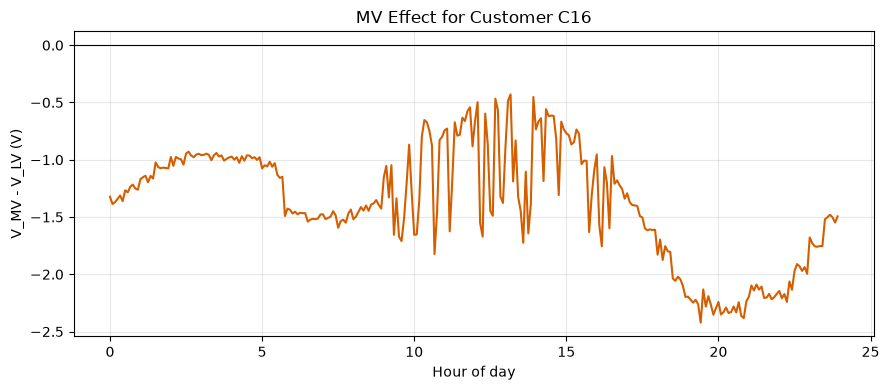

In [2]:
CUSTOMER_TO_INSPECT = 16
DAY_TO_INSPECT = 1

customer_index = CUSTOMER_TO_INSPECT - 1
start = (DAY_TO_INSPECT - 1) * STEPS_PER_DAY
end = start + STEPS_PER_DAY
customer_effect = mv_effect_test[start:end, customer_index]

print(f"Customer C{CUSTOMER_TO_INSPECT}, test day {DAY_TO_INSPECT}")
print(f"Mean MV effect: {customer_effect.mean():.4f} V")
print(f"Std. MV effect: {customer_effect.std():.4f} V")

plt.figure(figsize=(9, 4))
plt.plot(hours, customer_effect, color="#D55E00")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Hour of day")
plt.ylabel("V_MV - V_LV (V)")
plt.title(f"MV Effect for Customer C{CUSTOMER_TO_INSPECT}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### E.1 Answer

For C16 on test day 1, the mean MV effect is about **−1.3820 V** and its standard deviation is about **0.4947 V**. Its time-varying shape is consistent with the feeder-wide upstream movement identified in the tutorial, although individual customers can retain smaller residual differences.


## 3. E.2: Check Whether Vref Helps Customers Consistently

Calculate the absolute and relative per-customer RMSE reductions, then identify the largest reduction and count how many customers improve.


,customer,P/Q only RMSE (V),P/Q + Vref RMSE (V),absolute RMSE reduction (V),relative reduction (%)
0,4,0.5629,0.0128,0.5501,97.7284
1,5,0.6945,0.0143,0.6802,97.9410
2,6,0.6298,0.0126,0.6172,97.9993
3,7,0.5643,0.0090,0.5554,98.4126
4,8,0.7018,0.0168,0.6850,97.6061
5,9,0.6254,0.0107,0.6147,98.2865
6,10,0.5609,0.0095,0.5514,98.3118
7,11,0.6990,0.0108,0.6882,98.4538
8,12,0.6283,0.0101,0.6182,98.3923
9,13,0.5649,0.0061,0.5587,98.9135


Largest absolute reduction: C20, 0.6903 V
Customers improved: 28/28


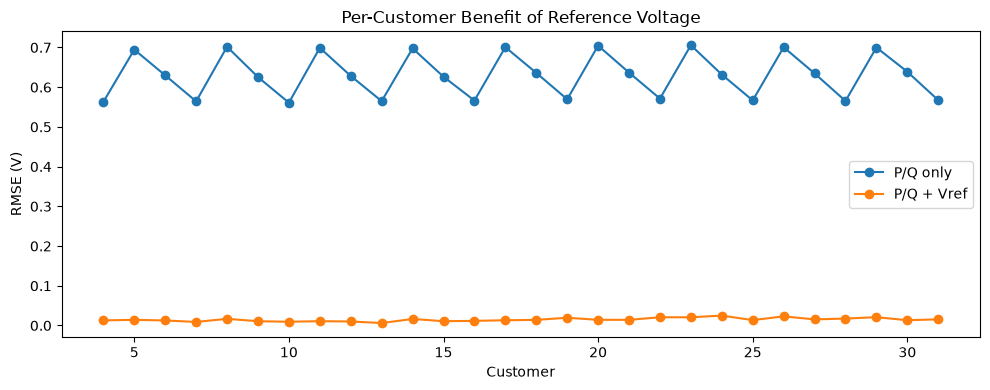

In [3]:
customer_benefit = per_customer_metrics.copy()
customer_benefit["absolute RMSE reduction (V)"] = (
    customer_benefit["P/Q only RMSE (V)"]
    - customer_benefit["P/Q + Vref RMSE (V)"]
)
customer_benefit["relative reduction (%)"] = (
    100
    * customer_benefit["absolute RMSE reduction (V)"]
    / customer_benefit["P/Q only RMSE (V)"]
)

largest_reduction = customer_benefit.sort_values(
    "absolute RMSE reduction (V)",
    ascending=False,
).iloc[0]
customers_improved = int(
    (customer_benefit["absolute RMSE reduction (V)"] > 0).sum()
)

display(customer_benefit.round(4))
print(
    "Largest absolute reduction: "
    f"C{int(largest_reduction['customer'])}, "
    f"{largest_reduction['absolute RMSE reduction (V)']:.4f} V"
)
print(f"Customers improved: {customers_improved}/{len(customer_benefit)}")

plt.figure(figsize=(10, 4))
plt.plot(
    customer_benefit["customer"],
    customer_benefit["P/Q only RMSE (V)"],
    marker="o",
    label="P/Q only",
)
plt.plot(
    customer_benefit["customer"],
    customer_benefit["P/Q + Vref RMSE (V)"],
    marker="o",
    label="P/Q + Vref",
)
plt.xlabel("Customer")
plt.ylabel("RMSE (V)")
plt.title("Per-Customer Benefit of Reference Voltage")
plt.legend()
plt.tight_layout()
plt.show()

### E.2 Answer

All **28/28** non-reference customers improve after Vref is added. C20 has the largest absolute RMSE reduction, about **0.6903 V**. The benefit is therefore widespread rather than limited to a few customers.

## 4. E.3: Use topology to explain MV-effect differences

Compare the mean RMS MV-effect magnitude across phases, then calculate its relationship with upstream hops within each phase.

,mean,minimum,maximum
phase,,,
1,1.4677,1.4658,1.4685
2,1.4402,1.4389,1.4408
3,1.3780,1.3768,1.3785


Correlation between hops and RMS magnitude within each phase:


phase
1    0.9655
2    0.9818
3    0.9707
dtype: float64

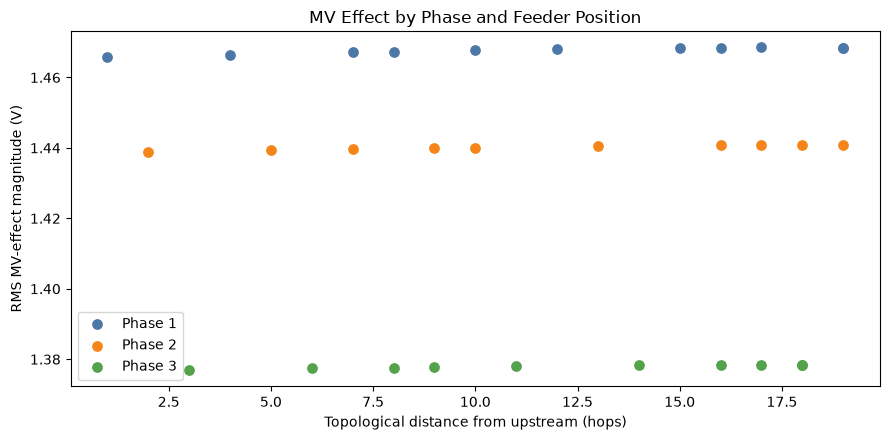

In [4]:
phase_summary = (
    customer_mv_effect.groupby("phase")["RMS MV effect (V)"]
    .agg(mean="mean", minimum="min", maximum="max")
)
phase_correlations = customer_mv_effect.groupby("phase").apply(
    lambda group: group["hops"].corr(group["RMS MV effect (V)"]),
    include_groups=False,
)

display(phase_summary.round(4))
print("Correlation between hops and RMS magnitude within each phase:")
display(phase_correlations.round(4))

phase_colours = {1: "#4C78A8", 2: "#F58518", 3: "#54A24B"}
plt.figure(figsize=(9, 4.5))
for phase, group in customer_mv_effect.groupby("phase"):
    plt.scatter(
        group["hops"],
        group["RMS MV effect (V)"],
        label=f"Phase {phase}",
        color=phase_colours[phase],
        s=45,
    )

plt.xlabel("Topological distance from upstream (hops)")
plt.ylabel("RMS MV-effect magnitude (V)")
plt.title("MV Effect by Phase and Feeder Position")
plt.legend()
plt.tight_layout()
plt.show()

### E.3 Answer

The mean RMS MV-effect magnitude is approximately **1.4677 V**, **1.4402 V** and **1.3780 V** for phases 1, 2 and 3, respectively. Within each phase, its correlation with upstream hops is strongly positive (about **0.97**, **0.98** and **0.97**). In this simulated feeder, the upstream change therefore affects every customer, with a clear phase grouping and a smaller position-dependent increase within each phase.